<a href="https://colab.research.google.com/github/esb-index/Barka-AV/blob/main/Dynamic_Network_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
torque_matrix_out = []

for s_t in state_matrix:
    tau_t = np.dot(interaction_matrix, s_t)
    torque_matrix_out.append(tau_t)

torque_matrix_out = np.array(torque_matrix_out)

torque_df_out = pd.DataFrame(
    torque_matrix_out,
    index=years,
    columns=component_columns
)

print("\n2025 torque (OUT orientation):")
print(torque_df_out.loc[2025])



2025 torque (OUT orientation):
P1      5.0135
P2      5.4750
P3      7.9705
P4      4.7000
P5      6.9350
P6      6.6190
P7      9.6125
P8     10.6580
P9      4.7510
P10     7.8370
F1     12.4410
F2     10.5370
F3      5.9785
F4     10.8090
F5      9.4460
F6      6.3020
F7      6.9300
F8     10.0740
F9      9.8770
F10     8.3910
Name: 2025.0, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# -----------------------------
# PARAMÉTEREK
# -----------------------------

THRESHOLD = 17.0
UNCERTAINTY = 0.20
N_SIM = 10000
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

# -----------------------------
# ADATOK BETÖLTÉSE
# -----------------------------

state_df = pd.read_csv("7x20.csv", index_col=0)
interaction_df = pd.read_csv("20x20.csv", header=None)

component_columns = [
    "P1","P2","P3","P4","P5","P6","P7","P8","P9","P10",
    "F1","F2","F3","F4","F5","F6","F7","F8","F9","F10"
]

years = state_df.index.astype(float).values

state_matrix = state_df[component_columns].values / 100.0
interaction_matrix = interaction_df.iloc[1:, 1:].values.astype(float) / 100.0

# -----------------------------
# FÁZIS 1 — Determinisztikus torque
# -----------------------------

torque_matrix = []

for s_t in state_matrix:
    tau_t = np.dot(interaction_matrix, s_t)
    torque_matrix.append(tau_t)

torque_matrix = np.array(torque_matrix)

torque_df = pd.DataFrame(
    torque_matrix,
    index=years,
    columns=component_columns
)

print("\nDeterministic torque table:")
print(torque_df)

# -----------------------------
# FÁZIS 2 — Trend + Threshold year
# -----------------------------

def quad_func(x, a, b, c):
    return a*x**2 + b*x + c

future_years = np.linspace(years[0], 2050, 200)

threshold_years = {}

for comp in component_columns:
    y_data = torque_df[comp].values
    popt, _ = curve_fit(quad_func, years, y_data)
    forecast = quad_func(future_years, *popt)

    idx = np.where(forecast >= THRESHOLD)[0]
    if len(idx) > 0:
        threshold_years[comp] = future_years[idx[0]]
    else:
        threshold_years[comp] = np.nan

threshold_df = pd.DataFrame.from_dict(
    threshold_years, orient="index", columns=["ThresholdYear"]
).sort_values("ThresholdYear")

print("\nThreshold reach years:")
print(threshold_df)

# Legkorábbi
winner = threshold_df.index[0]
print(f"\nFirst component to reach threshold: {winner}")

# -----------------------------
# FÁZIS 3 — Monte Carlo a győztesre
# -----------------------------


mc_threshold_years = []

for sim in range(N_SIM):

    if sim % 500 == 0:
        print(f"Simulation {sim}")

    noise = np.random.uniform(
        1 - UNCERTAINTY,
        1 + UNCERTAINTY,
        size=interaction_matrix.shape
    )

    perturbed_A = interaction_matrix * noise

    sim_torque = []

    for s_t in state_matrix:
        tau_t = np.dot(perturbed_A, s_t)
        sim_torque.append(tau_t[winner_index])

    sim_torque = np.array(sim_torque)

    # GYORS regresszió
    coeffs = np.polyfit(years, sim_torque, 2)
    forecast = np.polyval(coeffs, future_years)

    idx = np.where(forecast >= THRESHOLD)[0]
    if len(idx) > 0:
        mc_threshold_years.append(future_years[idx[0]])

# ===============================
# CSV EXPORT BLOKK
# ===============================

# 1. Determinisztikus torque mátrix
torque_df.to_csv("deterministic_torque_1970_2025.csv")

# 2. Threshold évek komponensenként
threshold_df.to_csv("threshold_years_by_component.csv")

# 3. Monte Carlo eredmények (nyers)
mc_results_df = pd.DataFrame(
    mc_threshold_years,
    columns=[f"{winner}_threshold_year"]
)

mc_results_df.to_csv("mc_threshold_distribution_raw.csv", index=False)

# 4. Monte Carlo statisztika
mc_stats_df = pd.DataFrame({
    "Mean": [np.mean(mc_threshold_years)],
    "Median": [np.median(mc_threshold_years)],
    "Std": [np.std(mc_threshold_years)],
    "P2.5": [np.percentile(mc_threshold_years, 2.5)],
    "P97.5": [np.percentile(mc_threshold_years, 97.5)]
})

mc_stats_df.to_csv("mc_threshold_summary_statistics.csv", index=False)

print("\nCSV export completed successfully.")


print("\nMonte Carlo results:")
print("Mean threshold year:", np.mean(mc_threshold_years))
print("Median:", np.median(mc_threshold_years))
print("2.5 percentile:", np.percentile(mc_threshold_years, 2.5))
print("97.5 percentile:", np.percentile(mc_threshold_years, 97.5))



Deterministic torque table:
            P1      P2      P3      P4      P5      P6      P7       P8  \
1970.0  0.6855  0.7185  1.3410  0.2895  1.0910  0.7040  1.6125   1.8575   
1980.0  1.0470  1.0435  1.8610  0.8535  1.4845  1.2975  2.2665   2.6210   
1990.0  1.4925  1.6665  2.4635  1.3465  2.1595  1.9615  3.1750   3.6045   
2000.0  2.2550  2.4185  3.6745  2.2555  3.1705  3.0475  4.5415   5.1795   
2010.0  3.3635  3.6530  5.4920  3.3700  4.7735  4.5010  6.6140   7.4280   
2020.0  4.1400  4.4665  6.7160  4.1050  5.8205  5.4935  8.1375   9.0780   
2025.0  5.0135  5.4750  7.9705  4.7000  6.9350  6.6190  9.6125  10.6580   

            P9    P10      F1      F2      F3       F4     F5      F6     F7  \
1970.0  0.6465  1.154   2.008   1.971  1.1050   1.7085  1.732  1.3235  1.128   
1980.0  1.1525  1.832   3.068   2.818  1.6200   2.5465  2.340  1.7115  1.691   
1990.0  1.8290  2.629   4.240   3.896  2.2860   3.5230  3.091  2.0700  2.291   
2000.0  2.5340  3.734   6.127   5.339  3.1180   5.

In [ ]:
!pip install SALib

In [ ]:
import numpy as np
import pandas as pd
from SALib.sample import saltelli
from SALib.analyze import sobol

# =====================================
# 1. ADATOK BEOLVASÁSA + SKÁLÁZÁS
# =====================================

df_state = pd.read_csv("7x20.csv", index_col=0) / 100.0
A = pd.read_csv("20x20.csv", index_col=0).values / 100.0

years = df_state.index.astype(int)

state_1970 = df_state.loc[1970].values
state_2025 = df_state.loc[2025].values

component_names = list(df_state.columns)

# =====================================
# 2. F1 OSZLOP KIVÁLASZTÁSA
# =====================================

f1_index = component_names.index("F1")
A_f1_column = A[:, f1_index]

# csak a nem nulla interakciók
nonzero_indices = np.where(A_f1_column != 0)[0]

print("Nem nulla F1-be mutató élek száma:", len(nonzero_indices))

# =====================================
# 3. SOBOL PROBLÉMA DEFINÍCIÓ
# =====================================

problem = {
    'num_vars': len(nonzero_indices),
    'names': [f"{component_names[i]}_to_F1" for i in nonzero_indices],
    'bounds': [
        [0.8 * A_f1_column[i], 1.2 * A_f1_column[i]]
        for i in nonzero_indices
    ]
}

# =====================================
# 4. MINTAVÉTEL (2048)
# =====================================

param_values = saltelli.sample(problem, 2048, calc_second_order=False)

# =====================================
# 5. MODELLFÜGGVÉNY
# =====================================

def compute_f1_torque(params, state_vector):
    torque = 0
    for k, i in enumerate(nonzero_indices):
        torque += params[k] * state_vector[i]
    return torque

# =====================================
# 6. FUTTATÁS – 1970
# =====================================

Y_1970 = np.array([
    compute_f1_torque(p, state_1970)
    for p in param_values
])

Si_1970 = sobol.analyze(problem, Y_1970, calc_second_order=False)

# =====================================
# 7. FUTTATÁS – 2025
# =====================================

Y_2025 = np.array([
    compute_f1_torque(p, state_2025)
    for p in param_values
])

Si_2025 = sobol.analyze(problem, Y_2025, calc_second_order=False)

# =====================================
# 8. EREDMÉNYEK CSV EXPORT
# =====================================

results = pd.DataFrame({
    "Parameter": problem["names"],
    "S1_1970": Si_1970["S1"],
    "ST_1970": Si_1970["ST"],
    "S1_2025": Si_2025["S1"],
    "ST_2025": Si_2025["ST"]
})

results = results.sort_values("ST_2025", ascending=False)

results.to_csv("Sobol_F1_1970_2025.csv", index=False)

print("\nSobol analysis completed.")
print("\nTop 5 legfontosabb él 2025-ben:")
print(results.head())


Nem nulla F1-be mutató élek száma: 17


/tmp/ipython-input-3265399684.py:49: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 2048, calc_second_order=False)



Sobol analysis completed.

Top 5 legfontosabb él 2025-ben:
    Parameter   S1_1970   ST_1970   S1_2025   ST_2025
7   P10_to_F1  0.000000  0.000000  0.244940  0.244932
6    P8_to_F1  0.000000  0.000000  0.188069  0.188075
1    P3_to_F1  0.000000  0.000000  0.140956  0.141011
5    P7_to_F1  0.086701  0.086694  0.081624  0.081635
12   F5_to_F1  0.064921  0.064924  0.057516  0.057503


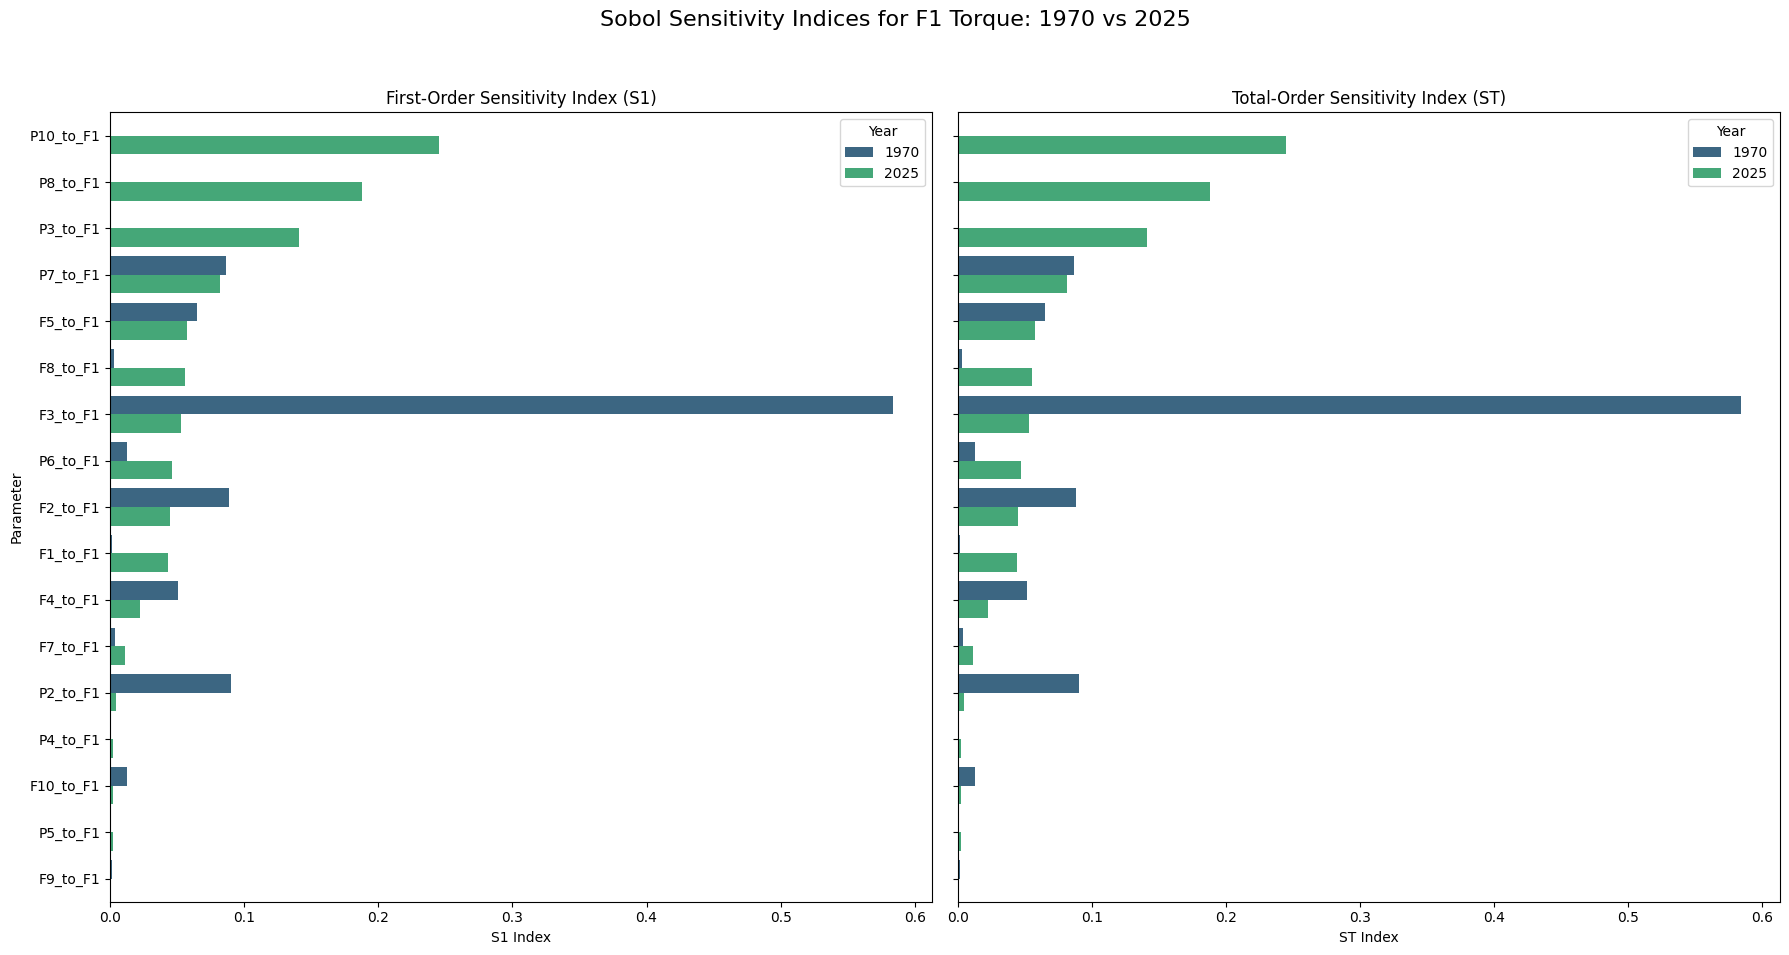

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'results' DataFrame is sorted by ST_2025 for better visualization
results_sorted = results.sort_values("ST_2025", ascending=False).copy()

# Melt the DataFrame for easier plotting
melted_results = results_sorted.melt(id_vars=['Parameter'],
                                     value_vars=['S1_1970', 'ST_1970', 'S1_2025', 'ST_2025'],
                                     var_name='Metric',
                                     value_name='Sensitivity_Index')

# Separate 'Metric' into 'Type' (S1/ST) and 'Year' (1970/2025)
melted_results['Type'] = melted_results['Metric'].apply(lambda x: x.split('_')[0])
melted_results['Year'] = melted_results['Metric'].apply(lambda x: x.split('_')[1])

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharey=True)
fig.suptitle('Sobol Sensitivity Indices for F1 Torque: 1970 vs 2025', fontsize=16)

# Plot S1 indices
sns.barplot(x='Sensitivity_Index', y='Parameter', hue='Year', data=melted_results[melted_results['Type'] == 'S1'], ax=axes[0], palette='viridis')
axes[0].set_title('First-Order Sensitivity Index (S1)')
axes[0].set_xlabel('S1 Index')
axes[0].set_ylabel('Parameter')
axes[0].legend(title='Year')

# Plot ST indices
sns.barplot(x='Sensitivity_Index', y='Parameter', hue='Year', data=melted_results[melted_results['Type'] == 'ST'], ax=axes[1], palette='viridis')
axes[1].set_title('Total-Order Sensitivity Index (ST)')
axes[1].set_xlabel('ST Index')
axes[1].set_ylabel('') # Remove y-label for the second plot as it's shared
axes[1].legend(title='Year')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# ============================================================
# 8.3 OUTGOING STRUCTURAL SENSITIVITY OF F1
# Sobol analysis – F1 → j propagation
# ============================================================
!pip install SALib

import numpy as np
import pandas as pd
from SALib.sample import saltelli
from SALib.analyze import sobol

# ------------------------------------------------------------
# 1. Adatok beolvasása
# ------------------------------------------------------------

A_df = pd.read_csv("20x20.csv", index_col=0)
S_df = pd.read_csv("7x20.csv", index_col=0)

# Skálázás (korrekció a spreadsheet 100x hibára)
A = A_df.values.astype(float) / 100.0
S = S_df.values.astype(float) / 100.0

components = list(A_df.columns)

# F1 index meghatározása
f1_index = components.index("F1")

# ------------------------------------------------------------
# 2. Vizsgált élek: F1 → j (nem nulla értékek)
# ------------------------------------------------------------

outgoing_indices = []
bounds = []
names = []

for j in range(len(components)):
    val = A[f1_index, j]
    if val != 0:
        outgoing_indices.append(j)
        names.append(f"F1_to_{components[j]}")
        bounds.append([0.8 * val, 1.2 * val])

k = len(outgoing_indices)

problem = {
    "num_vars": k,
    "names": names,
    "bounds": bounds
}

print(f"Vizsgált F1→j élek száma: {k}")

# ------------------------------------------------------------
# 3. Sobol minta (N=2048)
# ------------------------------------------------------------

N = 2048
param_values = saltelli.sample(problem, N, calc_second_order=False)

# ------------------------------------------------------------
# 4. Modell definíció
# ------------------------------------------------------------

def compute_torque_for_year(year_index):

    s = S[year_index, :]
    Y = []

    for params in param_values:

        A_sim = A.copy()

        # F1 sor módosítása
        for idx, j in enumerate(outgoing_indices):
            A_sim[f1_index, j] = params[idx]

        tau = np.dot(A_sim.T, s)  # sor → oszlop logika

        # Most minden j torque-ját eltároljuk
        Y.append(tau)

    return np.array(Y)


# ------------------------------------------------------------
# 5. Elemzés 1970 és 2025-re
# ------------------------------------------------------------

years = S_df.index.astype(int).tolist()
idx_1970 = years.index(1970)
idx_2025 = years.index(2025)

results = {}

for label, idx in [("1970", idx_1970), ("2025", idx_2025)]:

    Y = compute_torque_for_year(idx)

    # Most minden célkomponensre külön Sobol!
    sobol_results = {}

    for j in outgoing_indices:

        Sj = sobol.analyze(
            problem,
            Y[:, j],
            calc_second_order=False,
            print_to_console=False
        )

        sobol_results[components[j]] = {
            "S1": Sj["S1"].sum(),
            "ST": Sj["ST"].sum()
        }

    results[label] = sobol_results

# ------------------------------------------------------------
# 6. DataFrame létrehozása
# ------------------------------------------------------------

df_out = []

for comp in components:
    if comp in results["1970"]:

        df_out.append({
            "Component": comp,
            "ST_1970": results["1970"][comp]["ST"],
            "ST_2025": results["2025"][comp]["ST"]
        })

df_out = pd.DataFrame(df_out)
df_out.to_csv("Sobol_F1_outgoing_1970_2025.csv", index=False)

print("Kimenő Sobol eredmények elmentve.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 16.3 MB/s eta 0:00:00
Vizsgált F1→j élek száma: 20


/tmp/ipython-input-1643478651.py:58: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=False)


Kimenő Sobol eredmények elmentve.


In [ ]:
!pip install SALib

import numpy as np
import pandas as pd
from SALib.sample import saltelli
from SALib.analyze import sobol

# ============================================================
# 1. ADATBETÖLTÉS
# ============================================================

# Állapotmátrix
df_state = pd.read_csv('7x20.csv', index_col=0)

# Teljes 20x20 interakciós mátrix (CSV-re konvertálva!)
A_full = pd.read_csv('20x20.csv', index_col=0)

# Normalizálás (!!!)
S0 = df_state.loc[2025].values.astype(float) / 100.0
A = A_full.values.astype(float) / 100.0

component_names = A_full.columns.tolist()

# F1 index meghatározása
f1_index = component_names.index('F1')

# ============================================================
# 2. SOBOL PROBLÉMA DEFINÍCIÓ
# ============================================================

f1_row = A[f1_index, :]

bounds = []
for val in f1_row:
    if val == 0:
        bounds.append([0, 0.001])
    else:
        bounds.append([0.8 * val, 1.2 * val])

problem = {
    'num_vars': 20,
    'names': component_names,
    'bounds': bounds
}

# ============================================================
# 3. SALTELLI MINTÁZÁS (2048)
# ============================================================

param_values = saltelli.sample(problem, 2048, calc_second_order=False)

# ============================================================
# 4. MODELL DEFINÍCIÓ (10 ITERÁCIÓ)
# ============================================================

def propagate_model(params):

    results = []

    for p in params:

        A_temp = A.copy()
        A_temp[f1_index, :] = p  # F1 sor perturbálása

        M = np.eye(20) + A_temp.T

        S = S0.copy()

        # 10 iteráció
        for _ in range(1):
            S = M @ S

        results.append(S)

    return np.array(results)

Y = propagate_model(param_values)

# ============================================================
# 5. SOBOL ELEMZÉS (ST index minden komponensre)
# ============================================================

sobol_results = []

for j in range(20):

    Si = sobol.analyze(problem, Y[:, j], calc_second_order=False)

    sobol_results.append({
        "Component": component_names[j],
        "ST": Si['ST'].mean(),
        "ST_conf": Si['ST_conf'].mean()
    })

df_results = pd.DataFrame(sobol_results)

df_results.to_csv("Sobol_F1_propagation_2025_1_iter.csv", index=False)

print("Kész. Eredmény mentve: Sobol_F1_propagation_2025_10iter.csv")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 23.1 MB/s eta 0:00:00


/tmp/ipython-input-3441546289.py:50: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 2048, calc_second_order=False)


Kész. Eredmény mentve: Sobol_F1_propagation_2025_10iter.csv


In [ ]:
import numpy as np
import pandas as pd

# Kritikus nyomaték
CRITICAL = 17

# Iterációk száma
n_iter = 2

S = S0.copy()

history = []
collapse_info = []

for k in range(n_iter):

    # 1. Lineáris propagáció
    S = S + A.T @ S

    # 2. Torque számítás (ha torque külön van számolva, akkor azt hívd!)
    torque = S.copy()   # ha az állapot maga a torque

    # 3. Kritikus állapot ellenőrzés
    collapsed = np.abs(torque) >= CRITICAL

    collapse_info.append(collapsed)
    history.append(torque.copy())

# DataFrame-be rendezés
df_history = pd.DataFrame(history, columns=component_names)
df_collapse = pd.DataFrame(collapse_info, columns=component_names)

df_history.index = [f"iter_{i+1}" for i in range(n_iter)]
df_collapse.index = [f"iter_{i+1}" for i in range(n_iter)]

df_history.to_csv("F1_propagation_2iter_states.csv")
df_collapse.to_csv("F1_propagation_2iter_collapse.csv")

print("Kész.")


Kész.


In [ ]:
import pandas as pd
import numpy as np

# Betöltés
A = pd.read_csv("20x20.csv", index_col=0).values / 100.0
S = pd.read_csv("7x20.csv", index_col=0)

components = S.columns.tolist()

# 2025 állapot
s_2025 = S.loc[2025].values / 100.0

# F1 index
f1_index = components.index("F1")

# Teljes torque 2025
tau_2025 = A.T @ s_2025

# F1 hatás erőssége
climate_leverage = A[f1_index, :]

# Kritikus közelség (17-es küszöb)
distance_to_threshold = 17 - np.abs(tau_2025)

df = pd.DataFrame({
    "Component": components,
    "F1_leverage": climate_leverage,
    "Abs_Leverage": np.abs(climate_leverage),
    "Torque_2025": tau_2025,
    "Distance_to_17": distance_to_threshold
})

df_sorted = df.sort_values("Abs_Leverage", ascending=False)

df_sorted.head(10)


,Component,F1_leverage,Abs_Leverage,Torque_2025,Distance_to_17
3,P4,1.0,1.0,7.6200,9.3800
15,F6,1.0,1.0,8.1490,8.8510
9,P10,1.0,1.0,4.5950,12.4050
11,F2,1.0,1.0,10.4530,6.5470
13,F4,1.0,1.0,9.4990,7.5010
17,F8,0.9,0.9,5.9220,11.0780
2,P3,0.9,0.9,11.3655,5.6345
14,F5,0.9,0.9,10.9085,6.0915
6,P7,0.9,0.9,12.0615,4.9385
0,P1,0.8,0.8,9.6490,7.3510


In [ ]:
!pip install SALib

import numpy as np
import pandas as pd
from SALib.sample import saltelli
from SALib.analyze import sobol

# ============================================================
# 1. BETÖLTÉS
# ============================================================

A = pd.read_csv("20x20.csv", index_col=0).values / 100.0
S = pd.read_csv("7x20.csv", index_col=0)

components = S.columns.tolist()
s_2025 = S.loc[2025].values / 100.0

f1_index = components.index("F1")

# ============================================================
# 2. SOBOL PROBLÉMA (F1 teljes sora)
# ============================================================

f1_row = A[f1_index, :]

bounds = []
for val in f1_row:
    if val == 0:
        bounds.append([0, 0.001])
    else:
        bounds.append([0.8 * val, 1.2 * val])

problem = {
    "num_vars": 20,
    "names": components,
    "bounds": bounds
}

# ============================================================
# 3. SALTELLI MINTÁZÁS
# ============================================================

param_values = saltelli.sample(problem, 2048, calc_second_order=False)

# ============================================================
# 4. MONTE CARLO TORQUE SZÁMÍTÁS
# ============================================================

Y = []

for params in param_values:
    A_mod = A.copy()
    A_mod[f1_index, :] = params

    tau = A_mod.T @ s_2025
    Y.append(tau)

Y = np.array(Y)

# ============================================================
# 5. SOBOL ELEMZÉS MINDEN KOMPONENSRE
# ============================================================

results = []

for j in range(20):
    Si = sobol.analyze(problem, Y[:, j], calc_second_order=False)

    results.append({
        "Component": components[j],
        "ST_mean": np.mean(Si["ST"]),
        "ST_std": np.std(Si["ST"])
    })

df_results = pd.DataFrame(results)
df_results.sort_values("ST_mean", ascending=False).to_csv(
    "Sobol_F1_outgoing_torque_2025.csv", index=False
)

print("Kész.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 19.4 MB/s eta 0:00:00


/tmp/ipython-input-4275169397.py:43: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 2048, calc_second_order=False)


Kész.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# ============================================================
# 1. BETÖLTÉS
# ============================================================

# Torque idősor (1970–2025)
df_tau = pd.read_csv("Torque_timeseries.csv", index_col=0)

# Interakciós mátrix
A = pd.read_csv("20x20.csv", index_col=0).values / 100.0

components = df_tau.columns.tolist()

# 2025 torque
tau_2025 = df_tau.loc[2025].values

# F1 index
f1_index = components.index("F1")

# F1 hatásvektor
F1_leverage = np.abs(A[f1_index, :])

# ============================================================
# 2. TREND MEREDekség SZÁMÍTÁSA
# ============================================================

years = df_tau.index.values.reshape(-1, 1)

trend_slopes = []

for comp in components:
    y = df_tau[comp].values
    model = LinearRegression()
    model.fit(years, y)
    trend_slopes.append(abs(model.coef_[0]))

trend_slopes = np.array(trend_slopes)

# ============================================================
# 3. KRITIKUS KÜSZÖB KÖZELSÉG
# ============================================================

epsilon = 0.01
distance_factor = 1 / (epsilon + (17 - np.abs(tau_2025)))

# ============================================================
# 4. CARI SZÁMÍTÁS
# ============================================================

CARI = trend_slopes * F1_leverage * distance_factor

df_cari = pd.DataFrame({
    "Component": components,
    "Trend_slope": trend_slopes,
    "F1_leverage": F1_leverage,
    "Torque_2025": tau_2025,
    "Distance_factor": distance_factor,
    "CARI": CARI
})

df_cari_sorted = df_cari.sort_values("CARI", ascending=False)

df_cari_sorted.to_csv("CARI_results_2025.csv", index=False)

print("Kész. Eredmény mentve: CARI_results_2025.csv")


Kész. Eredmény mentve: CARI_results_2025.csv


In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# 1. BETÖLTÉS
# ============================================================

df_tau = pd.read_csv("Torque_timeseries.csv", index_col=0)
A = pd.read_csv("20x20.csv", index_col=0).values / 100.0

components = df_tau.columns.tolist()
years = df_tau.index.values

f1_index = components.index("F1")
F1_leverage = np.abs(A[f1_index, :])

# ============================================================
# 2. KVADRATIKUS ILLESZTÉS + 2040 PROJEKCIÓ
# ============================================================

tau_2040 = []
slope_2040 = []

for comp in components:
    y = df_tau[comp].values

    # y = a t^2 + b t + c
    a, b, c = np.polyfit(years, y, 2)

    # 2040 torque
    tau_pred = a*2040**2 + b*2040 + c
    tau_2040.append(tau_pred)

    # lokális derivált 2040-ben
    local_slope = 2*a*2040 + b
    slope_2040.append(abs(local_slope))

tau_2040 = np.array(tau_2040)
slope_2040 = np.array(slope_2040)

# ============================================================
# 3. KÜSZÖB-KÖZELSÉG 2040
# ============================================================

epsilon = 0.01
distance_2040 = 1 / (epsilon + (17 - np.abs(tau_2040)))

# ============================================================
# 4. CARI 2040
# ============================================================

CARI_2040 = slope_2040 * F1_leverage * distance_2040

df_result = pd.DataFrame({
    "Component": components,
    "Projected_Torque_2040": tau_2040,
    "Local_Slope_2040": slope_2040,
    "F1_leverage": F1_leverage,
    "Distance_factor_2040": distance_2040,
    "CARI_2040": CARI_2040
})

df_sorted = df_result.sort_values("CARI_2040", ascending=False)

df_sorted.to_csv("CARI_2040_BAU_quadratic.csv", index=False)

df_sorted.head(10)


,Component,Projected_Torque_2040,Local_Slope_2040,F1_leverage,Distance_factor_2040,CARI_2040
13,F4,15.189691,0.320690,1.0,0.549357,0.176174
11,F2,14.424758,0.286238,1.0,0.386811,0.110720
7,P8,14.879296,0.313659,0.7,0.469329,0.103046
17,F8,14.058289,0.293919,0.9,0.338787,0.089618
6,P7,13.523394,0.292064,0.9,0.286812,0.075391
14,F5,13.428582,0.294316,0.9,0.279219,0.073961
2,P3,11.376647,0.253880,0.9,0.177514,0.040561
9,P10,10.783268,0.224168,1.0,0.160598,0.036001
18,F9,13.712096,0.279980,0.4,0.303223,0.033959
19,F10,11.378369,0.221711,0.7,0.177568,0.027558


In [ ]:
import numpy as np
import pandas as pd

# ==============================
# 1. ADATOK BETÖLTÉSE
# ==============================

df_tau = pd.read_csv("Torque_timeseries.csv", index_col=0)
A = pd.read_csv("20x20.csv", index_col=0).values / 100.0

components = df_tau.columns.tolist()
years = df_tau.index.values

f1_index = components.index("F1")
F1_leverage = np.abs(A[f1_index, :])

# ==============================
# 2. QUADRATIKUS TREND + 2040 BAU
# ==============================

tau_2040 = []
slope_2040 = []
residual_std = []

for comp in components:
    y = df_tau[comp].values

    a, b, c = np.polyfit(years, y, 2)

    # 2040 előrejelzés
    tau_pred = a*2040**2 + b*2040 + c
    tau_2040.append(tau_pred)

    # lokális derivált 2040-ben
    local_slope = 2*a*2040 + b
    slope_2040.append(abs(local_slope))

    # trend illesztési bizonytalanság
    y_fit = a*years**2 + b*years + c
    residuals = y - y_fit
    residual_std.append(np.std(residuals))

tau_2040 = np.array(tau_2040)
slope_2040 = np.array(slope_2040)
residual_std = np.array(residual_std)

# ==============================
# 3. PARAMÉTEREK
# ==============================

epsilon_values = [0.001, 0.01, 0.05]
threshold_values = [16.5, 17.0, 17.5]

# ==============================
# 4. EPSZILON + KÜSZÖB ROBUSZTUSSÁG
# ==============================

print("\n=== EPSILON + THRESHOLD SENSITIVITY ===\n")

for eps in epsilon_values:
    for taucrit in threshold_values:

        distance = 1 / (eps + (taucrit - np.abs(tau_2040)))
        CARI = slope_2040 * F1_leverage * distance

        df_temp = pd.DataFrame({
            "Component": components,
            "CARI": CARI
        }).sort_values("CARI", ascending=False)

        print(f"\nEpsilon = {eps}, Threshold = {taucrit}")
        print(df_temp.head(5))

# ==============================
# 5. TREND BIZONYTALANSÁG (±1σ)
# ==============================

eps = 0.01
taucrit = 17.0
distance = 1 / (eps + (taucrit - np.abs(tau_2040)))

slope_plus = slope_2040 + residual_std
slope_minus = np.maximum(0, slope_2040 - residual_std)

CARI_plus = slope_plus * F1_leverage * distance
CARI_minus = slope_minus * F1_leverage * distance

df_plus = pd.DataFrame({
    "Component": components,
    "CARI_plus": CARI_plus
}).sort_values("CARI_plus", ascending=False)

df_minus = pd.DataFrame({
    "Component": components,
    "CARI_minus": CARI_minus
}).sort_values("CARI_minus", ascending=False)

print("\n=== TREND UNCERTAINTY +1σ ===")
print(df_plus.head(5))

print("\n=== TREND UNCERTAINTY -1σ ===")
print(df_minus.head(5))



=== EPSILON + THRESHOLD SENSITIVITY ===


Epsilon = 0.001, Threshold = 16.5
   Component      CARI
13        F4  0.244557
11        F2  0.137863
7         P8  0.135389
17        F8  0.108293
6         P7  0.088278

Epsilon = 0.001, Threshold = 17.0
   Component      CARI
13        F4  0.177049
11        F2  0.111107
7         P8  0.103483
17        F8  0.089892
6         P7  0.075586

Epsilon = 0.001, Threshold = 17.5
   Component      CARI
10        F1  0.543841
13        F4  0.138748
11        F2  0.093048
7         P8  0.083748
17        F8  0.076837

Epsilon = 0.01, Threshold = 16.5
   Component      CARI
13        F4  0.242890
11        F2  0.137268
7         P8  0.134642
17        F8  0.107895
6         P7  0.088012

Epsilon = 0.01, Threshold = 17.0
   Component      CARI
13        F4  0.176174
11        F2  0.110720
7         P8  0.103046
17        F8  0.089618
6         P7  0.075391

Epsilon = 0.01, Threshold = 17.5
   Component      CARI
10        F1  0.529099
13        F4  0

In [ ]:
import numpy as np
import pandas as pd

# ==============================
# 1. LOAD INTERACTION MATRIX
# ==============================

df_A = pd.read_csv("20x20.csv", index_col=0)
A = df_A.values / 100.0   # normalize if originally 0–100

components = df_A.columns.tolist()

# ==============================
# 2. F1 UNIT PERTURBATION VECTOR
# ==============================

f1_index = components.index("F1")

e = np.zeros(len(components))
e[f1_index] = 1.0

# ==============================
# 3. CASCADE PROPAGATION
# ==============================

K = 3   # short-horizon window

Ak = np.identity(len(components))
energy = np.zeros(len(components))

for k in range(1, K+1):
    Ak = np.matmul(Ak, A)
    delta = np.matmul(Ak, e)
    energy += np.abs(delta)

# ==============================
# 4. REMOVE SELF-AMPLICATION
# ==============================

energy[f1_index] = 0

# ==============================
# 5. RANK COMPONENTS
# ==============================

df_result = pd.DataFrame({
    "Component": components,
    "AmplificationEnergy": energy
}).sort_values("AmplificationEnergy", ascending=False)

print("\n=== LARGEST IMMEDIATE TORQUE AMPLIFICATION ===\n")
print(df_result.head(10))



=== LARGEST IMMEDIATE TORQUE AMPLIFICATION ===

   Component  AmplificationEnergy
7         P8             65.66400
17        F8             60.77500
11        F2             60.36075
13        F4             60.17575
14        F5             56.54975
6         P7             56.48000
18        F9             53.10025
2         P3             49.83175
19       F10             49.27900
9        P10             49.16025


In [ ]:
import numpy as np
import pandas as pd

# ==============================
# 1. LOAD INTERACTION MATRIX
# ==============================

df_A = pd.read_csv("20x20.csv", index_col=0)
A = df_A.values / 100.0   # normalize if needed

components = df_A.columns.tolist()

# ==============================
# 2. EIGEN ANALYSIS
# ==============================

eigenvalues, eigenvectors = np.linalg.eig(A)

# Spectral radius
spectral_radius = np.max(np.abs(eigenvalues))

# Index of dominant eigenvalue
idx_max = np.argmax(np.abs(eigenvalues))

dominant_lambda = eigenvalues[idx_max]
dominant_vector = np.real(eigenvectors[:, idx_max])

# Normalize eigenvector (absolute contribution)
dominant_vector_abs = np.abs(dominant_vector)
dominant_vector_abs = dominant_vector_abs / np.sum(dominant_vector_abs)

# ==============================
# 3. RANK COMPONENTS
# ==============================

df_eigen = pd.DataFrame({
    "Component": components,
    "DominantEigenvectorWeight": dominant_vector_abs
}).sort_values("DominantEigenvectorWeight", ascending=False)

print("\n=== SPECTRAL ANALYSIS ===\n")
print(f"Spectral radius: {spectral_radius}")
print(f"Dominant eigenvalue: {dominant_lambda}\n")

print("Top components in dominant instability mode:\n")
print(df_eigen.head(10))



=== SPECTRAL ANALYSIS ===

Spectral radius: 9.874589022310964
Dominant eigenvalue: (9.874589022310964+0j)

Top components in dominant instability mode:

   Component  DominantEigenvectorWeight
10        F1                   0.077404
7         P8                   0.069713
11        F2                   0.065853
13        F4                   0.064720
17        F8                   0.064457
14        F5                   0.060789
6         P7                   0.059203
18        F9                   0.058544
19       F10                   0.054360
2         P3                   0.051402


In [ ]:
import numpy as np
import pandas as pd

# ================================
# 1. LOAD MATRIX CORRECTLY
# ================================

# Feltöltés (ha még nincs betöltve)
from google.colab import files
uploaded = files.upload()

# Beolvasás: első oszlop index
df = pd.read_csv("20x20.csv", index_col=0)

print("Loaded matrix shape:", df.shape)

if df.shape != (20, 20):
    raise ValueError("Matrix is not 20x20 after loading. Check CSV structure.")

# Google Sheets scaling correction
A = df.values.astype(float) / 100.0


# ================================
# 2. ORIGINAL SPECTRAL ANALYSIS
# ================================

eigvals, eigvecs = np.linalg.eig(A)

spectral_radius = np.max(np.abs(eigvals))
dominant_index = np.argmax(np.abs(eigvals))

dominant_eigenvalue = eigvals[dominant_index]
dominant_eigenvector = np.real(eigvecs[:, dominant_index])

print("\n=== ORIGINAL SPECTRAL ANALYSIS ===")
print("Spectral radius:", spectral_radius)
print("Dominant eigenvalue:", dominant_eigenvalue)


# ================================
# 3. NORMALIZED JACOBIAN
# ================================

A_norm = A / spectral_radius

eigvals_norm, eigvecs_norm = np.linalg.eig(A_norm)

rho_norm = np.max(np.abs(eigvals_norm))
dom_index_norm = np.argmax(np.abs(eigvals_norm))

dom_eigval_norm = eigvals_norm[dom_index_norm]
dom_eigvec_norm = np.real(eigvecs_norm[:, dom_index_norm])

print("\n=== NORMALIZED JACOBIAN ===")
print("Spectral radius (should be ~1):", rho_norm)
print("Dominant eigenvalue:", dom_eigval_norm)


# ================================
# 4. STRUCTURAL BACKBONE RANKING
# ================================

components = df.index.tolist()

results = pd.DataFrame({
    "Component": components,
    "DominantEigenvectorWeight": dom_eigvec_norm
})

# Normalizálás publikációbarát formára
results["DominantEigenvectorWeight"] = (
    results["DominantEigenvectorWeight"] /
    np.sum(np.abs(results["DominantEigenvectorWeight"]))
)

results_sorted = results.reindex(
    results["DominantEigenvectorWeight"].abs().sort_values(ascending=False).index
)

print("\n=== TOP COMPONENTS IN NORMALIZED DOMINANT MODE ===\n")
print(results_sorted.head(10))


# ================================
# 5. SAVE OUTPUT
# ================================

results_sorted.to_csv("normalized_dominant_mode.csv", index=False)
print("\nSaved as normalized_dominant_mode.csv")


Saving 20x20.csv to 20x20 (1).csv
Loaded matrix shape: (20, 20)

=== ORIGINAL SPECTRAL ANALYSIS ===
Spectral radius: 9.874589022310964
Dominant eigenvalue: (9.874589022310964+0j)

=== NORMALIZED JACOBIAN ===
Spectral radius (should be ~1): 0.9999999999999978
Dominant eigenvalue: (0.9999999999999978+0j)

=== TOP COMPONENTS IN NORMALIZED DOMINANT MODE ===

   Component  DominantEigenvectorWeight
10        F1                   0.077404
7         P8                   0.069713
11        F2                   0.065853
13        F4                   0.064720
17        F8                   0.064457
14        F5                   0.060789
6         P7                   0.059203
18        F9                   0.058544
19       F10                   0.054360
2         P3                   0.051402

Saved as normalized_dominant_mode.csv
